# Modelo JoinPoint (Borrador)

In [1]:
# [Librerías Importadas]

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
from sklearn.model_selection import train_test_split
import pwlf


In [2]:
df = pd.read_csv("C:\Dengue_caracterization\DATA_LAST\Datos Modelos\datos_completos.csv")
print(df.head())

  municipio   año  periodo  casos  ciclo_vital_adolescencia  \
0   BARANOA  2018        2      1                         1   
1   BARANOA  2018        4      1                         0   
2   BARANOA  2018        5      1                         0   
3   BARANOA  2018        6      2                         0   
4   BARANOA  2018        7      3                         0   

   ciclo_vital_adulto  ciclo_vital_adulto_mayor  ciclo_vital_infante_mayor  \
0                   0                         0                          0   
1                   1                         0                          0   
2                   1                         0                          0   
3                   2                         0                          0   
4                   1                         0                          2   

   ciclo_vital_infante_menor  regimen_salud_contributivo  ...  sexo_femenino  \
0                          0                           1  ...           

## Correlación y Colinealidad

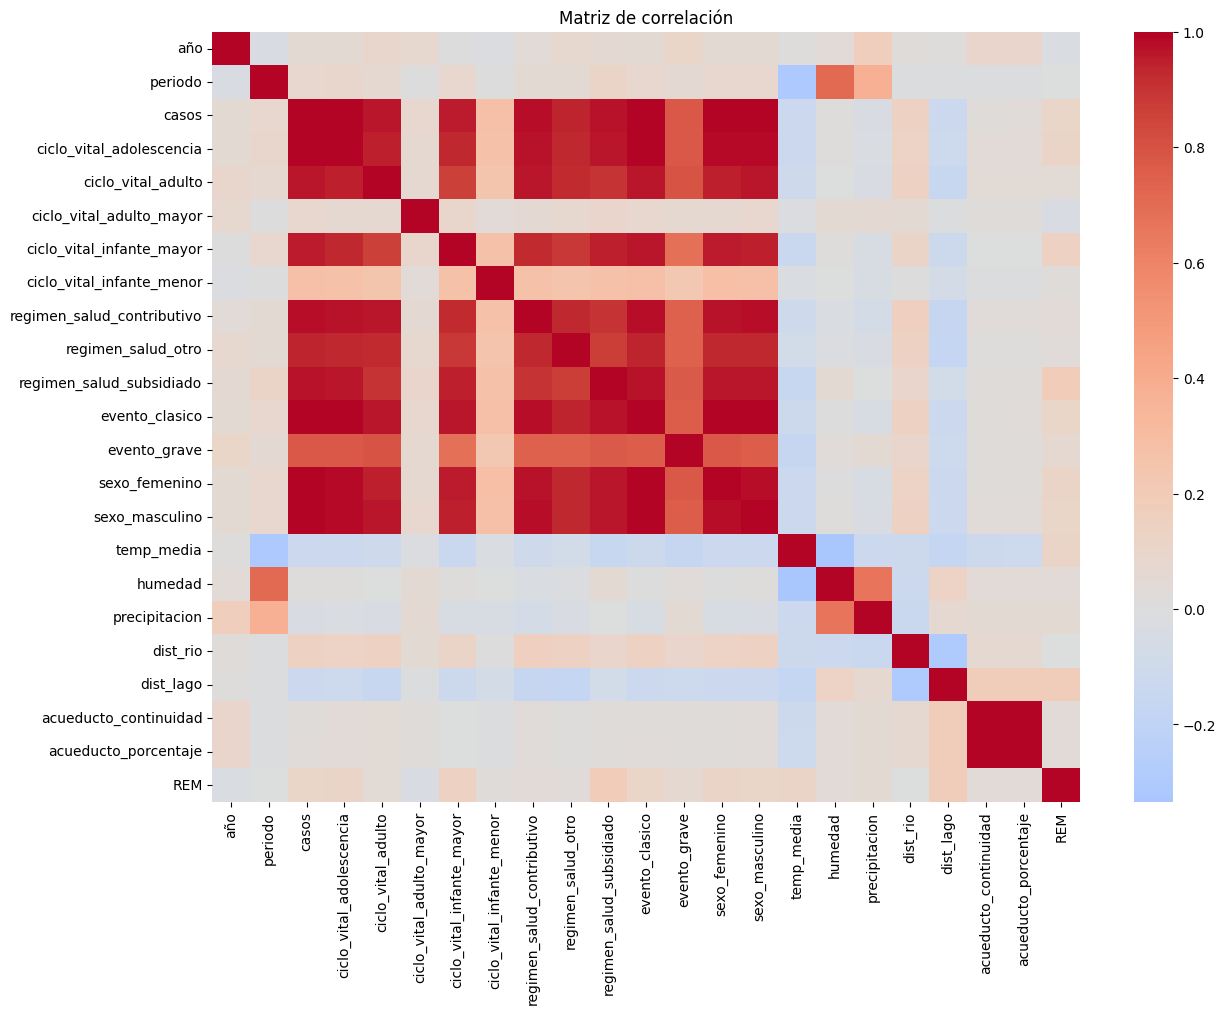

REM                           1.000000
regimen_salud_subsidiado      0.188669
dist_lago                     0.180336
ciclo_vital_infante_mayor     0.142461
ciclo_vital_adolescencia      0.114097
temp_media                    0.110604
sexo_femenino                 0.110516
evento_clasico                0.108167
casos                         0.107502
sexo_masculino                0.103815
evento_grave                  0.063375
precipitacion                 0.049492
ciclo_vital_adulto            0.046342
regimen_salud_contributivo    0.039813
humedad                       0.037980
acueducto_continuidad         0.031973
acueducto_porcentaje          0.031151
regimen_salud_otro            0.030319
ciclo_vital_infante_menor     0.016089
periodo                      -0.000510
dist_rio                     -0.002625
año                          -0.025323
ciclo_vital_adulto_mayor     -0.032723
Name: REM, dtype: float64


In [4]:
# [Correlación entre Variables]

# Nos quedamos solo con variables numéricas
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Correlación
corr = num_cols.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de correlación")
plt.show()

# Correlaciones respecto a REM
corr_REM = corr['REM'].sort_values(ascending=False)
print(corr_REM)

In [9]:
# Variables predictoras (excluir REM y variables categóricas como municipio)
df_vif = df.drop(columns=['REM', 'municipio','año','periodo'])

# Dataset limpio de NaN
df_vif = df_vif.dropna()

# Calcular VIF
vif = pd.DataFrame()
vif["variable"] = df_vif.columns
vif["VIF"] = [variance_inflation_factor(df_vif.values, i)
              for i in range(df_vif.shape[1])]

display(vif.sort_values(by="VIF", ascending=False))

c:\Users\TAWTOCA\anaconda3\envs\machine\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variable,VIF
0,casos,inf
1,ciclo_vital_adolescencia,inf
2,ciclo_vital_adulto,inf
3,ciclo_vital_adulto_mayor,inf
4,ciclo_vital_infante_mayor,inf
5,ciclo_vital_infante_menor,inf
6,regimen_salud_contributivo,inf
7,regimen_salud_otro,inf
8,regimen_salud_subsidiado,inf
9,evento_clasico,inf


## Prueba Modelo

In [5]:
df_model = df.sort_values(by=["municipio", "año", "periodo"])

df_model = df_model.dropna(subset=["REM"])

df_model["t"] = df_model["año"] + df_model["periodo"] / 100


In [7]:

y = df_model["REM"].values
x = df_model["t"].values

bic_scores = []
models = []
rss_values = []

n = len(x)

for n_segments in range(1, 5):  # 1 a 4 segmentos
    model = pwlf.PiecewiseLinFit(x, y)
    model.fit(n_segments)
    
    # Calcular RSS
    y_hat = model.predict(x)
    rss = np.sum((y - y_hat)**2)
    rss_values.append(rss)
    
    # Número de parámetros:
    # n_segments parámetros de pendiente/intercepto
    # (n_segments - 1) joinpoints
    k = n_segments + (n_segments - 1)
    
    # Fórmula BIC
    bic = n * np.log(rss/n) + k * np.log(n)
    bic_scores.append(bic)
    
    models.append(model)

best_index = np.argmin(bic_scores)
best_model = models[best_index]

print("Mejor número de segmentos:", best_index + 1)
print("Mejores joinpoints (t):", best_model.fit_breaks[1:-1])
print("BIC del mejor modelo:", bic_scores[best_index])


Mejor número de segmentos: 1
Mejores joinpoints (t): []
BIC del mejor modelo: 1979.6082751915606


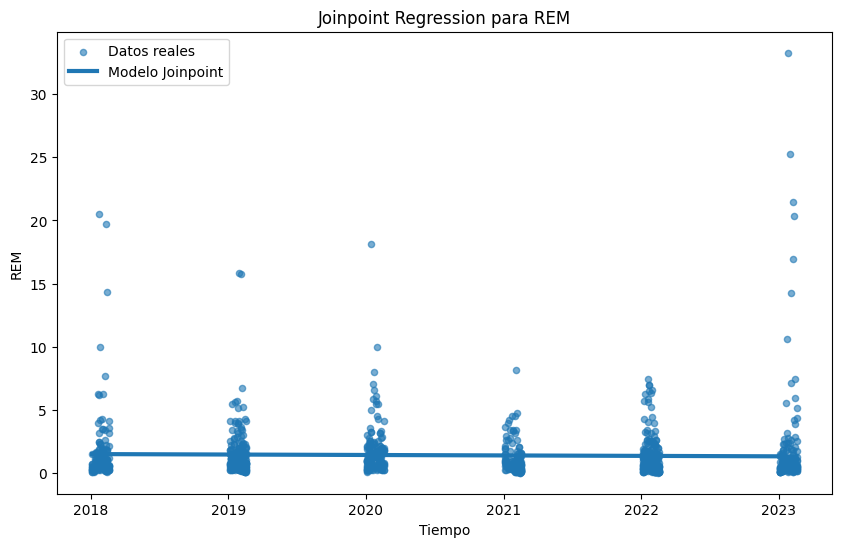

In [8]:
x_pred = np.linspace(x.min(), x.max(), 200)
y_pred = best_model.predict(x_pred)

plt.figure(figsize=(10,6))
plt.scatter(x, y, s=20, alpha=0.6, label="Datos reales")
plt.plot(x_pred, y_pred, linewidth=3, label="Modelo Joinpoint")
plt.xlabel("Tiempo")
plt.ylabel("REM")
plt.title("Joinpoint Regression para REM")
plt.legend()
plt.show()
